<div style="background:#005A67;padding:28px;border-radius:18px;color:white">
  <p style="margin:0;color:#F6BD38;font-weight:700;letter-spacing:1px">PROJETO INTEGRADOR · FUNDAMENTOS DE IA E PROGRAMAÇÃO</p>
  <h1 style="margin:8px 0 4px">Rota em Dia</h1>
  <h3 style="margin:0;font-weight:400">Por que os ônibus fretados estão chegando atrasados?</h3>
</div>

**Equipe:** Juliana Ballin Lima · Fernanda de Oliveira da Costa · Pedro Henrique Oliveira Dias  
**Período analisado:** fevereiro a maio de 2026 · **Escopo:** 8 rotas e 3 turnos

[Consultar o relatório técnico descritivo](https://github.com/JulianaBallin/TransitTrace/blob/main/docs/relatorio/relatorio_tecnico_rota_em_dia.pdf)

> **Pergunta central:** por que os atrasos aumentaram, onde se concentram e quais evidências sustentam a explicação mais plausível?

## Como executar no Google Colab

1. Faça upload deste notebook e do arquivo `projeto_integrador_transporte_fretado.csv` na mesma sessão.
2. Clique em **Ambiente de execução > Executar tudo**.
3. Se o CSV não for encontrado, a primeira célula solicitará o upload.

O notebook preserva a base bruta em `raw` e cria a base tratada em `data`. Nenhuma correção é feita silenciosamente.

In [1]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

CREAM = "#FFF8E8"
TEAL = "#005A67"
MINT = "#65C3A5"
CORAL = "#F06449"
YELLOW = "#F6BD38"
INK = "#17343A"
GRAY = "#A7B0B3"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": CREAM,
    "axes.facecolor": CREAM,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "grid.color": "#D8E0E0",
})

def parse_dates(values):
    # Lê os dois formatos de data da base sem inverter dia e mês.
    text = values.astype("string").str.strip()
    is_iso = text.str.fullmatch(r"\d{4}-\d{2}-\d{2}").fillna(False)
    parsed = pd.to_datetime(text.where(is_iso), format="%Y-%m-%d", errors="coerce")
    return parsed.fillna(
        pd.to_datetime(text.where(~is_iso), format="%d/%m/%Y", errors="coerce")
    )

In [2]:
candidates = [
    Path("dataset/projeto_integrador_transporte_fretado.csv"),
    Path("projeto_integrador_transporte_fretado.csv"),
    Path("/content/projeto_integrador_transporte_fretado.csv"),
]
data_path = next((path for path in candidates if path.exists()), None)

if data_path is None:
    from google.colab import files
    uploaded = files.upload()
    csv_name = next(name for name in uploaded if name.endswith(".csv"))
    data_path = Path(csv_name)

raw = pd.read_csv(data_path)
print(f"Arquivo: {data_path}")
print(f"Dimensão: {raw.shape[0]} linhas × {raw.shape[1]} colunas")

Arquivo: dataset/projeto_integrador_transporte_fretado.csv
Dimensão: 2463 linhas × 11 colunas


## Roteiro da investigação

| Etapa | Pergunta | Produto |
|---|---|---|
| 1 · Primeiro diagnóstico | O que parece estar acontecendo? | Indicadores iniciais e hipóteses concorrentes |
| 2 · Estatística | Onde, quando e com que intensidade? | Comparações, variabilidade e hipóteses atualizadas |
| 3 · Limpeza | Podemos confiar nos dados? | Pipeline, validação e comparação antes × depois |
| 4 · EDA | Qual explicação é mais plausível? | Cinco visualizações, conclusão e recomendações |

**Regra de leitura:** evidência observada, interpretação, hipótese e limitação aparecem separadas ao longo do notebook.

# Etapa 1 · Primeiro diagnóstico

Nesta etapa a base é observada como foi recebida. Não corrigimos rótulos, duplicatas ou valores extremos.

In [3]:
preview = raw.head(6)
display(preview)

parsed_dates = parse_dates(raw["data"])
diagnosis = pd.DataFrame({
    "informação": ["Linhas", "Colunas", "Início", "Fim", "Dias de operação"],
    "valor": [
        len(raw),
        raw.shape[1],
        parsed_dates.min().strftime("%d/%m/%Y"),
        parsed_dates.max().strftime("%d/%m/%Y"),
        parsed_dates.nunique(),
    ],
})
display(diagnosis)
display(raw.dtypes.rename("tipo").to_frame())

,data,turno,rota,zona_origem,empresa,horario_previsto,horario_chegada,atraso_min,passageiros,chuva_mm,ocorrencia
0,2026-02-02,Manhã,R01,Norte,Viação Alfa,05:45,05:44,-1,33,0.0,Nenhuma
1,2026-02-02,manha,R02,Norte,Viação Alfa,05:45,05:43,-2,34,0.0,Nenhuma
2,2026-02-02,Manhã,R03,Leste,Viação Beta,05:45,05:36,-9,39,0.0,Nenhuma
3,2026-02-02,Manhã,R04,Sul,Viação Alfa,05:45,05:39,-6,120,0.0,Nenhuma
4,2026-02-02,Manhã,R05,Leste,Viação Beta,05:45,05:42,-3,35,0.0,Nenhuma
5,2026-02-02,Manhã,R06,Oeste,Viação Alfa,05:45,05:42,7,41,0.0,Nenhuma


,informação,valor
0,Linhas,2463
1,Colunas,11
2,Início,02/02/2026
3,Fim,30/05/2026
4,Dias de operação,102


,tipo
data,str
turno,str
rota,str
zona_origem,str
empresa,str
horario_previsto,str
horario_chegada,str
atraso_min,int64
passageiros,int64
chuva_mm,float64


### Indicador principal

Uma viagem é **pontual** quando chega no máximo 5 minutos após o horário previsto.

**Pontualidade (%) = viagens com atraso ≤ 5 min ÷ total de viagens × 100.**

O atraso acima de 15 minutos é analisado separadamente, pois o ônibus deveria chegar 15 minutos antes do início do turno.

In [4]:
raw_analysis = raw.assign(pontual=raw["atraso_min"].le(5))

overall_raw = pd.DataFrame({
    "indicador": ["Pontualidade", "Mediana do atraso", "Chegadas após o início do turno"],
    "resultado": [
        f"{raw_analysis['pontual'].mean() * 100:.1f}%",
        f"{raw_analysis['atraso_min'].median():.0f} min",
        f"{raw_analysis['atraso_min'].gt(15).sum()} viagens",
    ],
})
display(overall_raw)

def punctuality_table(frame, group):
    return (
        frame.groupby(group, dropna=False)["pontual"]
        .agg(viagens="size", pontualidade="mean")
        .assign(pontualidade=lambda table: table["pontualidade"] * 100)
        .sort_values("pontualidade")
        .round(1)
    )

display(punctuality_table(raw_analysis, "rota").head(12))
display(punctuality_table(raw_analysis, "turno"))

standard_labels = (
    raw_analysis["rota"].astype(str).str.fullmatch(r"R\d{2}")
    & raw_analysis["turno"].isin(["Manhã", "Tarde", "Noite"])
)
print(f"Rota × turno (somente {standard_labels.sum()} linhas com rótulos já padronizados):")
display(
    raw_analysis[standard_labels]
    .pivot_table(index="rota", columns="turno", values="pontual", aggfunc="mean")
    .reindex(columns=["Manhã", "Tarde", "Noite"])
    .mul(100).round(1)
)

,indicador,resultado
0,Pontualidade,81.4%
1,Mediana do atraso,-1 min
2,Chegadas após o início do turno,125 viagens


,viagens,pontualidade
rota,,
Rota 05,2,0.0
R3,2,50.0
Rota 08,2,50.0
r05,6,50.0
R05,300,64.7
R1,3,66.7
R5,3,66.7
R03,299,67.6
r04,4,75.0


,viagens,pontualidade
turno,,
tarde,20,65.0
Manhã,805,76.1
Tarde,801,77.9
MANHÃ,10,80.0
noite,6,83.3
Noite,808,90.2
Noturno,7,100.0
manha,6,100.0


Rota × turno (somente 2341 linhas com rótulos já padronizados):


turno,Manhã,Tarde,Noite
rota,,,
R01,84.2,89.0,88.5
R02,82.3,80.6,89.0
R03,49.0,59.8,93.7
R04,82.5,84.4,92.9
R05,49.5,57.3,89.4
R06,89.8,85.9,89.2
R07,86.6,84.8,90.0
R08,83.5,81.6,90.8


### O que chama atenção antes da limpeza

- R03 e R05 aparecem entre as rotas menos pontuais, mesmo com rótulos fragmentados.
- Manhã e tarde parecem piores que o turno noturno.
- No cruzamento rota × turno, R03 e R05 ficam entre 49% e 60% de pontualidade na manhã e na tarde e entre 89% e 94% na noite; as demais rotas ficam entre 80% e 93% em todos os turnos.
- A média do atraso é maior que a mediana, sinal de assimetria e valores extremos.
- Há grafias diferentes para a mesma rota e o mesmo turno, além de chuva ausente e lotação acima de 44 lugares.

### Hipóteses concorrentes iniciais

| Hipótese | Evidência inicial | O que ainda precisamos verificar |
|---|---|---|
| H1 · Chuva | O período é chuvoso e há viagens com chuva forte | Se o efeito ocorre em todas as rotas e datas |
| H2 · Corredor R03/R05 | As duas rotas têm menor pontualidade | Quando a piora começa e se o turno noturno também muda |
| H3 · Ocorrências pontuais | Pane, trânsito, pneu e obra aparecem na base | Se casos isolados explicam a mudança sustentada |

**Pergunta investigativa:** a queda de pontualidade é geral por causa da chuva ou está concentrada em rotas, turnos e período específicos?

# Etapa 2 · Estatística descritiva

Comparamos tendência central, variabilidade, quartis, outliers, rotas, turnos, zonas, empresas e evolução temporal. A base ainda não foi corrigida, portanto as conclusões permanecem provisórias.

In [5]:
raw_stats = raw["atraso_min"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).rename({
    "count": "n", "mean": "média", "std": "desvio padrão",
    "min": "mínimo", "25%": "Q1", "50%": "mediana",
    "75%": "Q3", "95%": "P95", "99%": "P99", "max": "máximo",
})
display(raw_stats.round(2).to_frame("atraso_min"))

q1, q3 = raw["atraso_min"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
print(f"IQR: {iqr:.1f} min | limite superior: {upper_limit:.1f} min")
print(f"Possíveis outliers pelo IQR: {raw['atraso_min'].gt(upper_limit).sum()}")

,atraso_min
n,2463.00
média,2.51
desvio padrão,36.44
mínimo,-13.00
Q1,-4.00
mediana,-1.00
Q3,3.00
P95,16.00
P99,34.38
máximo,739.00


IQR: 7.0 min | limite superior: 13.5 min
Possíveis outliers pelo IQR: 172


In [6]:
canonical_rows = raw[
    raw["rota"].astype(str).str.fullmatch(r"R\d{2}")
    & raw["turno"].isin(["Manhã", "Tarde", "Noite"])
].copy()
canonical_rows["data_aux"] = parse_dates(canonical_rows["data"])
canonical_rows["pontual"] = canonical_rows["atraso_min"].le(5)

route_stats_raw = canonical_rows.groupby("rota").agg(
    viagens=("atraso_min", "size"),
    pontualidade=("pontual", "mean"),
    média=("atraso_min", "mean"),
    mediana=("atraso_min", "median"),
    desvio=("atraso_min", "std"),
    iqr=("atraso_min", lambda s: s.quantile(0.75) - s.quantile(0.25)),
)
route_stats_raw["pontualidade"] *= 100
display(route_stats_raw.round(1))

monthly_raw = canonical_rows.pivot_table(
    index="rota",
    columns=canonical_rows["data_aux"].dt.strftime("%Y-%m"),
    values="pontual",
    aggfunc="mean",
).mul(100)
display(monthly_raw.round(1))

,viagens,pontualidade,média,mediana,desvio,iqr
rota,,,,,,
R01,291,87.3,0.1,-2.0,7.2,6.0
R02,289,84.1,2.5,-1.0,42.8,6.0
R03,292,67.1,3.8,1.0,9.9,12.0
R04,292,86.6,4.7,-2.0,59.8,6.0
R05,289,65.1,6.1,1.0,44.3,13.0
R06,299,88.3,-0.5,-2.0,6.6,5.0
R07,296,87.2,1.7,-2.0,42.6,5.0
R08,293,85.3,2.5,-2.0,42.5,6.0


data_aux,2026-02,2026-03,2026-04,2026-05
rota,,,,
R01,91.0,81.3,87.7,89.5
R02,88.1,73.6,89.5,85.1
R03,92.8,77.3,52.6,47.2
R04,94.0,79.2,79.2,94.7
R05,93.9,76.3,54.1,38.4
R06,91.5,81.8,85.9,94.5
R07,94.0,74.7,85.1,96.1
R08,88.1,81.8,80.8,90.8


In [7]:
for group in ["zona_origem", "empresa"]:
    table = canonical_rows.groupby(group).agg(
        viagens=("atraso_min", "size"),
        pontualidade=("pontual", "mean"),
        mediana=("atraso_min", "median"),
        iqr=("atraso_min", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    )
    table["pontualidade"] *= 100
    display(table.sort_values("pontualidade").round(1))

print("Rotas por zona de origem e por empresa:")
display(canonical_rows.groupby("rota")[["zona_origem", "empresa"]].agg(lambda s: s.mode().iloc[0]).T)

,viagens,pontualidade,mediana,iqr
zona_origem,,,,
Leste,581,66.1,1.0,12.0
Norte,873,85.6,-2.0,6.0
Sul,292,86.6,-2.0,6.0
Centro-Sul,296,87.2,-2.0,5.0
Oeste,299,88.3,-2.0,5.0


,viagens,pontualidade,mediana,iqr
empresa,,,,
Viação Beta,1170,76.2,-1.0,9.0
Viação Alfa,1171,86.6,-2.0,6.0


Rotas por zona de origem e por empresa:


rota,R01,R02,R03,R04,R05,R06,R07,R08
zona_origem,Norte,Norte,Leste,Sul,Leste,Oeste,Centro-Sul,Norte
empresa,Viação Alfa,Viação Alfa,Viação Beta,Viação Alfa,Viação Beta,Viação Alfa,Viação Beta,Viação Beta


In [8]:
week_start = canonical_rows["data_aux"].dt.to_period("W-SUN").dt.start_time
weekly_raw = canonical_rows.pivot_table(
    index=week_start, columns="rota", values="pontual", aggfunc="mean"
).mul(100)
weekly_raw.index = weekly_raw.index.strftime("%d/%m")
weekly_raw.index.name = "semana (início)"
display(weekly_raw.round(0).style.format("{:.0f}").background_gradient(
    cmap="RdYlGn", vmin=0, vmax=100
))

iqr_limit = canonical_rows["atraso_min"].quantile(0.75) + 1.5 * (
    canonical_rows["atraso_min"].quantile(0.75) - canonical_rows["atraso_min"].quantile(0.25)
)
moderate = canonical_rows[
    canonical_rows["atraso_min"].gt(iqr_limit) & canonical_rows["atraso_min"].le(120)
]
in_target = moderate["rota"].isin(["R03", "R05"]) & moderate["data_aux"].ge("2026-04-06")
target_share = (
    canonical_rows["rota"].isin(["R03", "R05"]) & canonical_rows["data_aux"].ge("2026-04-06")
).mean()
print(f"Extremos acima de 120 min: {canonical_rows['atraso_min'].gt(120).sum()}")
print(f"Outliers moderados pelo IQR (até 120 min): {len(moderate)}")
print(f"  em R03/R05 desde 06/04: {in_target.sum()} ({in_target.mean() * 100:.0f}%), "
      f"embora esse recorte seja {target_share * 100:.0f}% das viagens")
display(canonical_rows[canonical_rows["atraso_min"].gt(120)][
    ["data", "rota", "turno", "horario_previsto", "horario_chegada", "atraso_min"]
])

rota,R01,R02,R03,R04,R05,R06,R07,R08
semana (início),,,,,,,,
02/02,94,88,94,94,100,82,94,100
09/02,94,81,100,100,83,100,94,88
16/02,87,94,88,88,94,89,94,89
23/02,89,88,88,94,100,94,94,78
02/03,94,88,88,89,89,88,89,89
09/03,76,68,76,65,81,67,61,83
16/03,76,69,83,88,59,78,84,82
23/03,78,69,72,74,76,90,67,72
30/03,88,88,72,81,85,94,76,81


Extremos acima de 120 min: 6
Outliers moderados pelo IQR (até 120 min): 159
  em R03/R05 desde 06/04: 70 (44%), embora esse recorte seja 12% das viagens


,data,rota,turno,horario_previsto,horario_chegada,atraso_min
411,2026-02-21,R02,Manhã,05:45,17:42,717
654,2026-03-05,R04,Manhã,05:45,17:46,721
1627,2026-04-21,R07,Manhã,05:45,17:49,724
1821,2026-04-30,R08,Manhã,05:45,17:39,714
2009,2026-05-09,R04,Manhã,05:45,17:44,719
2251,2026-05-21,R05,Manhã,05:45,18:04,739


### Respostas às perguntas investigativas

**Duas rotas com atraso médio semelhante apresentam a mesma variabilidade?** Não. R02 (média 2,5 min) e R03 (3,8 min) parecem próximas, mas o IQR de R03 é 12 min contra 6 min em R02: a variação típica de R03 é o dobro. O desvio padrão bruto engana na direção oposta: R02 tem 42,8 contra 9,9 em R03 só porque carrega um valor de 717 min. Para comparar variabilidade na base bruta, o IQR é mais confiável que o desvio padrão.

**O aumento acontece durante todo o período ou começa em determinado momento?** Em março todas as rotas pioram (74% a 82% de pontualidade), o que é compatível com o pico de chuva. Em abril as demais rotas voltam a 79%–90%, enquanto R03 e R05 caem para 53% e 54% e seguem em queda em maio. A tabela semanal mostra a quebra na semana de 06/04, e não uma deterioração gradual.

**Existe um grupo com comportamento mais instável?** A zona Leste (66%) e a Viação Beta (76%) têm as menores pontualidades, mas nenhuma das duas separa o problema sozinha: a zona Leste reúne apenas R03 e R05, e a Beta também opera R07 e R08, que ficam em 85% ou mais. O grupo instável é R03 + R05, não uma zona inteira nem uma empresa inteira.

**Um valor extremo representa um caso isolado ou faz parte de um padrão?** Depende do tamanho. Os seis valores entre 714 e 739 min são casos isolados: um por viagem, espalhados de fevereiro a maio e em cinco rotas diferentes. Já os outliers moderados pelo IQR formam padrão: R03/R05 desde 06/04 respondem por 70 dos 159 (44%), embora sejam só 12% das viagens.

### Leitura provisória das hipóteses

| Hipótese | Evidência a favor | Evidência contra ou limitação | Situação |
|---|---|---|---|
| H1 · Chuva | Atrasos crescem em dias mais chuvosos | Não explica por que duas rotas pioram muito mais | Aberta |
| H2 · Corredor R03/R05 | A piora mensal se concentra em R03 e R05 | A base ainda tem categorias e extremos inválidos | Ganhou força |
| H3 · Ocorrências pontuais | Pane produz atrasos severos | Casos esparsos não formam sozinhos uma ruptura | Perdeu força |

A média bruta não é confiável neste momento: valores acima de 700 minutos elevam o desvio padrão. A mediana é mais robusta, mas a origem desses extremos precisa ser auditada.

# Etapa 3 · Limpeza e validação

O pipeline segue quatro princípios: preservar a base bruta, declarar critérios, investigar antes de remover e não imputar informação desconhecida sem justificativa.

**Regras adotadas:**

- datas aceitam os formatos observados e são convertidas com dia primeiro;
- horários com `h` ou segundos são padronizados para `HH:MM`;
- rotas são reconstruídas pelo número e turnos recebem um mapa de equivalências;
- atraso é recalculado pelos horários, pois 12 linhas divergem do valor informado;
- atrasos fora de -60 a 120 minutos e passageiros fora de 0 a 44 viram ausentes, sem apagar a viagem;
- chuva ausente permanece ausente e não entra no gráfico chuva × atraso;
- duplicatas são removidas apenas quando todos os campos são iguais.

Antes de aplicar as regras, as duas decisões que apagam ou anulam informação são investigadas: duplicatas e atrasos acima de 120 minutos.

In [9]:
as_text = raw.astype("string").fillna("")
is_copy = raw.duplicated(keep="first")
right_after_original = as_text.eq(as_text.shift(1)).all(axis=1)
print(f"Cópias exatas: {is_copy.sum()}")
print(f"Cópias na linha imediatamente após o original: {right_after_original[is_copy].sum()}")
display(raw[is_copy].head(5))

extreme = raw[raw["atraso_min"].gt(120)].copy()
scheduled_raw = pd.to_datetime(extreme["horario_previsto"], format="%H:%M")
arrived_raw = pd.to_datetime(extreme["horario_chegada"], format="%H:%M")
extreme["atraso_se_menos_12h"] = (arrived_raw - scheduled_raw).dt.total_seconds() / 60 - 720
display(extreme[["data", "turno", "rota", "horario_previsto", "horario_chegada",
                 "atraso_min", "atraso_se_menos_12h"]])

Cópias exatas: 15
Cópias na linha imediatamente após o original: 15


,data,turno,rota,zona_origem,empresa,horario_previsto,horario_chegada,atraso_min,passageiros,chuva_mm,ocorrencia
90,2026-02-05,Noite,R02,Norte,Viação Alfa,21:45,21:46,1,40,20.7,Chuva forte
382,2026-02-19,Noite,r05,Leste,Viação Beta,21:45,21:44,-1,40,9.8,Nenhuma
471,2026-02-24,tarde,R05,Leste,Viação Beta,13:45,13:53,8,44,31.0,Chuva forte
664,2026-03-05,Tarde,R05,Leste,Viação Beta,13:45,13:42:00,-3,34,NaN,Nenhuma
750,2026-03-10,Manhã,R02,Norte,Viação Alfa,05:45,05:41,-4,38,1.8,Nenhuma


,data,turno,rota,horario_previsto,horario_chegada,atraso_min,atraso_se_menos_12h
411,2026-02-21,Manhã,R02,05:45,17:42,717,-3.0
654,2026-03-05,Manhã,R04,05:45,17:46,721,1.0
1627,2026-04-21,Manhã,R07,05:45,17:49,724,4.0
1821,2026-04-30,Manhã,R08,05:45,17:39,714,-6.0
2009,2026-05-09,Manhã,R04,05:45,17:44,719,-1.0
2251,2026-05-21,Manhã,R05,05:45,18:04,739,19.0


**Duplicatas:** as 15 cópias estão grudadas ao registro original, o padrão de uma linha digitada duas vezes. Cada rota faz uma viagem por turno e por dia, então uma segunda linha idêntica não pode ser outra viagem. Por isso a remoção é segura.

**Atrasos acima de 120 minutos:** os seis casos são do turno da manhã, previstos para 05:45, com chegada registrada entre 17:39 e 18:04. Subtrair 12 horas dá entre -6 e +19 minutos, valores normais para a operação. A leitura mais provável é um erro de AM/PM no registro do horário. É uma hipótese, não uma certeza, então o atraso fica ausente em vez de corrigido. O efeito é pequeno, 6 de 2.448 viagens, e nenhuma conclusão depende delas.

In [10]:
def clean_transport_data(raw_frame):
    data = raw_frame.copy()
    duplicate_mask = raw_frame.duplicated(keep="first")

    data["data"] = parse_dates(data["data"])
    data["turno"] = (
        data["turno"].astype("string").str.strip().str.casefold()
        .replace({"manha": "manhã", "noturno": "noite"}).str.title()
    )
    route_number = data["rota"].astype("string").str.extract(r"(\d+)", expand=False)
    data["rota"] = route_number.astype("Int64").map(
        lambda value: f"R{value:02d}" if pd.notna(value) else pd.NA
    )

    for column in ["zona_origem", "empresa", "ocorrencia"]:
        data[column] = data[column].astype("string").str.strip()
    for column in ["horario_previsto", "horario_chegada"]:
        data[column] = (
            data[column].astype("string").str.strip()
            .str.replace("h", ":", regex=False).str.slice(0, 5)
        )

    data = data.loc[~duplicate_mask].copy()
    scheduled = pd.to_datetime(
        data["data"].dt.strftime("%Y-%m-%d") + " " + data["horario_previsto"],
        errors="coerce",
    )
    arrived = pd.to_datetime(
        data["data"].dt.strftime("%Y-%m-%d") + " " + data["horario_chegada"],
        errors="coerce",
    )
    data["atraso_informado"] = data["atraso_min"]
    data["atraso_calculado"] = (arrived - scheduled).dt.total_seconds() / 60

    divergent = ~np.isclose(
        data["atraso_informado"], data["atraso_calculado"], equal_nan=True
    )
    invalid_delay = ~data["atraso_calculado"].between(-60, 120)
    invalid_capacity = ~data["passageiros"].between(0, 44)

    data["atraso_min"] = data["atraso_calculado"].mask(invalid_delay)
    data["passageiros"] = data["passageiros"].mask(invalid_capacity)
    data["pontual"] = data["atraso_min"].le(5).where(data["atraso_min"].notna())
    data["apos_inicio_turno"] = (
        data["atraso_min"].gt(15).where(data["atraso_min"].notna())
    )
    data["mes"] = data["data"].dt.to_period("M").astype("string")
    data["semana"] = data["data"].dt.to_period("W-SUN").apply(
        lambda period: period.start_time
    )
    data["periodo_ruptura"] = np.where(
        data["data"] < pd.Timestamp("2026-04-06"),
        "Antes de 06/04", "Desde 06/04"
    )
    data["grupo_rotas"] = np.where(
        data["rota"].isin(["R03", "R05"]), "R03 e R05", "Demais rotas"
    )

    log = pd.DataFrame([
        ["Categorias inconsistentes", "30 rotas e 8 turnos escritos", "Padronizar", "8 rotas e 3 turnos"],
        ["Valores ausentes", f"{raw_frame['chuva_mm'].isna().sum()} chuvas ausentes", "Manter NA", "Sem imputação"],
        ["Duplicados", f"{duplicate_mask.sum()} linhas idênticas", "Remover cópias", f"{len(raw_frame)} → {len(data)}"],
        ["Atraso divergente", f"{divergent.sum()} linhas", "Recalcular horários", "Indicador coerente"],
        ["Valores inválidos", f"{invalid_delay.sum()} atrasos; {invalid_capacity.sum()} lotações", "Marcar NA (atrasos: possível erro de 12 h)", "Viagens preservadas"],
    ], columns=["Problema", "Evidência", "Tratamento", "Impacto"])
    return data, log

data, cleaning_log = clean_transport_data(raw)
display(cleaning_log)

,Problema,Evidência,Tratamento,Impacto
0,Categorias inconsistentes,30 rotas e 8 turnos escritos,Padronizar,8 rotas e 3 turnos
1,Valores ausentes,145 chuvas ausentes,Manter NA,Sem imputação
2,Duplicados,15 linhas idênticas,Remover cópias,2463 → 2448
3,Atraso divergente,12 linhas,Recalcular horários,Indicador coerente
4,Valores inválidos,6 atrasos; 5 lotações,Marcar NA (atrasos: possível erro de 12 h),Viagens preservadas


In [11]:
comparison = pd.DataFrame({
    "indicador": ["Registros", "Rotas distintas", "Turnos distintos", "Atraso médio", "Pontualidade"],
    "antes": [
        len(raw), raw["rota"].nunique(), raw["turno"].nunique(),
        f"{raw['atraso_min'].mean():.2f} min", f"{raw['atraso_min'].le(5).mean() * 100:.1f}%"
    ],
    "depois": [
        len(data), data["rota"].nunique(), data["turno"].nunique(),
        f"{data['atraso_min'].mean():.2f} min", f"{data['pontual'].mean() * 100:.1f}%"
    ],
})
display(comparison)

checks = pd.Series({
    "datas inválidas": int(data["data"].isna().sum()),
    "chaves data × turno × rota duplicadas": int(data.duplicated(["data", "turno", "rota"]).sum()),
    "rotas fora de R01 a R08": int((~data["rota"].isin([f"R{i:02d}" for i in range(1, 9)])).sum()),
    "turnos fora do domínio": int((~data["turno"].isin(["Manhã", "Tarde", "Noite"])).sum()),
    "lotações válidas acima de 44": int(data["passageiros"].gt(44).sum()),
}, name="quantidade")
display(checks.to_frame())

,indicador,antes,depois
0,Registros,2463,2448
1,Rotas distintas,30,8
2,Turnos distintos,8,3
3,Atraso médio,2.51 min,0.70 min
4,Pontualidade,81.4%,81.9%


,quantidade
datas inválidas,0
chaves data × turno × rota duplicadas,0
rotas fora de R01 a R08,0
turnos fora do domínio,0
lotações válidas acima de 44,0


### Análises da Etapa 2 recalculadas na base tratada

In [12]:
route_stats = data.groupby("rota").agg(
    viagens=("atraso_min", "size"),
    pontualidade=("pontual", "mean"),
    média=("atraso_min", "mean"),
    mediana=("atraso_min", "median"),
    desvio=("atraso_min", "std"),
    iqr=("atraso_min", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    após_turno=("apos_inicio_turno", "sum"),
)
route_stats["pontualidade"] *= 100
display(route_stats.round(1))

monthly = data.pivot_table(
    index="rota", columns="mes", values="pontual", aggfunc="mean"
).mul(100)
display(monthly.round(1))

for group in ["zona_origem", "empresa"]:
    table = data.groupby(group).agg(
        viagens=("atraso_min", "size"),
        pontualidade=("pontual", "mean"),
        mediana=("atraso_min", "median"),
        iqr=("atraso_min", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    )
    table["pontualidade"] *= 100
    display(table.sort_values("pontualidade").round(1))

clean_stats = data["atraso_min"].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])
display(clean_stats.round(2).to_frame("atraso_min depois da limpeza"))

,viagens,pontualidade,média,mediana,desvio,iqr,após_turno
rota,,,,,,,
R01,306,87.908497,-0.0,-2.0,7.1,6.0,8
R02,306,84.918033,-0.0,-1.0,7.1,6.0,10
R03,306,68.300654,3.5,1.0,9.6,11.0,35
R04,306,87.171053,-0.2,-2.0,6.3,6.0,8
R05,306,64.262295,3.7,2.0,9.5,12.0,28
R06,306,88.562092,-0.6,-2.0,6.6,5.0,8
R07,306,88.196721,-0.9,-2.0,6.1,5.0,8
R08,306,85.901639,0.0,-2.0,7.9,6.0,11


mes,2026-02,2026-03,2026-04,2026-05
rota,,,,
R01,93.055556,80.769231,88.461538,89.74359
R02,90.140845,75.641026,88.461538,85.897436
R03,91.666667,79.487179,53.846154,50.0
R04,91.666667,80.519481,80.769231,96.103896
R05,94.444444,75.641026,51.282051,37.662338
R06,93.055556,80.769231,85.897436,94.871795
R07,94.444444,74.358974,88.311688,96.153846
R08,88.888889,80.769231,83.116883,91.025641


,viagens,pontualidade,mediana,iqr
zona_origem,,,,
Leste,612,66.284779,1.0,12.0
Norte,918,86.244541,-2.0,6.0
Sul,306,87.171053,-2.0,6.0
Centro-Sul,306,88.196721,-2.0,5.0
Oeste,306,88.562092,-2.0,5.0


,viagens,pontualidade,mediana,iqr
empresa,,,,
Viação Beta,1224,76.658477,-1.0,9.0
Viação Alfa,1224,87.141687,-2.0,6.0


,atraso_min depois da limpeza
count,2442.00
mean,0.70
std,7.81
min,-13.00
25%,-4.00
50%,-1.00
75%,3.00
95%,15.00
99%,32.00
max,59.00


### O que mudou após a limpeza

A média do atraso cai de 2,51 para 0,70 min e o desvio padrão de 36,4 para 7,8 min, porque os seis valores acima de 700 minutos deixam de distorcê-los; o máximo passa de 739 para 59 min. O desvio padrão agora é comparável entre rotas: R03 e R05 ficam perto de 9,5 min contra 6 a 8 nas demais. A mediana e o IQR gerais não mudam (-1 e 7 min). A pontualidade por rota e por mês mantém o mesmo desenho: R03 e R05 caem a partir de abril e as demais não. Portanto, a hipótese principal **sobrevive à limpeza**.

| Hipótese | Antes | Depois | Situação |
|---|---|---|---|
| H1 · Chuva | Associação aparente | Associação permanece, mas é geral | Mantida como fator agravante |
| H2 · Corredor R03/R05 | Piora concentrada | Padrão fica mais nítido e começa em 06/04 | Ganhou força |
| H3 · Ocorrências pontuais | Extremos severos | Explicam casos, não a ruptura inteira | Perdeu força |

# Etapa 4 · EDA e visualização

Cada gráfico responde uma pergunta. Depois de cada figura registramos evidência, interpretação, hipótese e limitação.

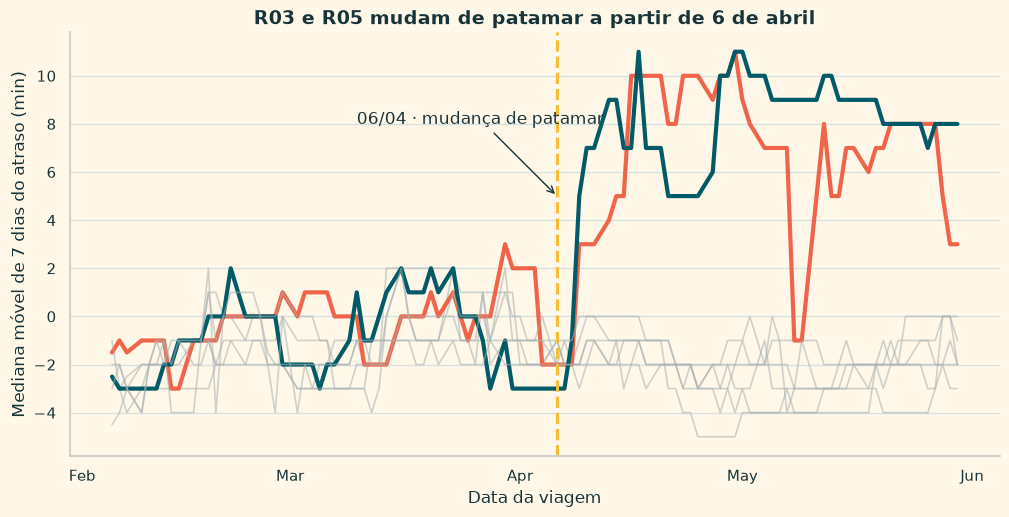

In [13]:
daily = (
    data.groupby(["data", "rota"])["atraso_min"].median().unstack()
    .rolling(7, min_periods=4).median()
)
fig, ax = plt.subplots(figsize=(12, 5.5))
for route in daily.columns:
    color, width, alpha = GRAY, 1.2, 0.55
    if route == "R03": color, width, alpha = CORAL, 3.0, 1
    if route == "R05": color, width, alpha = TEAL, 3.0, 1
    ax.plot(daily.index, daily[route], color=color, lw=width, alpha=alpha)
ax.axvline(pd.Timestamp("2026-04-06"), color=YELLOW, lw=2.2, ls="--")
ax.annotate("06/04 · mudança de patamar", xy=(pd.Timestamp("2026-04-06"), 5),
            xytext=(pd.Timestamp("2026-03-10"), 8),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.set(title="R03 e R05 mudam de patamar a partir de 6 de abril",
       xlabel="Data da viagem", ylabel="Mediana móvel de 7 dias do atraso (min)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(axis="x", visible=False)
sns.despine()
plt.show()

**Evidência:** até o início de abril, as oito rotas oscilam perto de zero; depois de 06/04, R03 e R05 ficam entre 7 e 15 minutos.  
**Interpretação:** houve uma ruptura localizada, não uma piora gradual de toda a operação.  
**Hipótese:** as duas rotas passaram a enfrentar uma restrição compartilhada no corredor.  
**Limitação:** a linha marca uma mudança observada, não prova qual evento a causou.

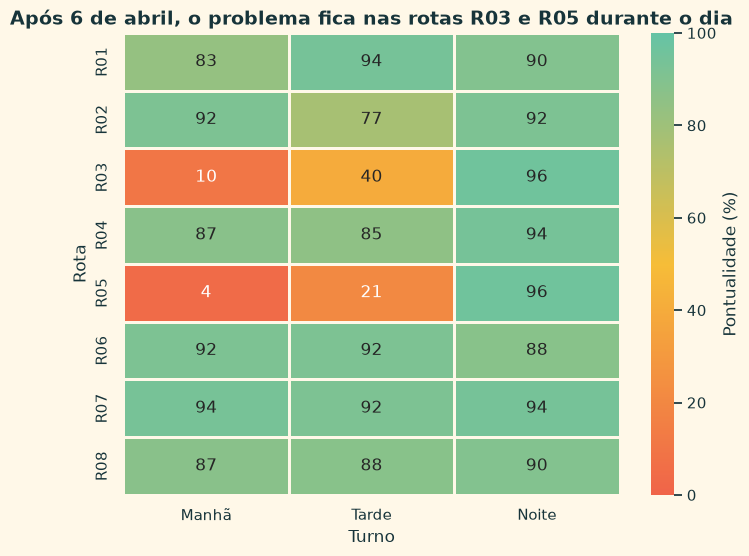

In [14]:
after_change = data[data["data"] >= "2026-04-06"]
heatmap = (
    after_change.pivot_table(index="rota", columns="turno", values="pontual", aggfunc="mean")
    .reindex(columns=["Manhã", "Tarde", "Noite"]).mul(100).astype(float)
)
cmap = sns.blend_palette([CORAL, YELLOW, MINT], as_cmap=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap, annot=True, fmt=".0f", vmin=0, vmax=100, cmap=cmap,
            linewidths=2, linecolor=CREAM, cbar_kws={"label": "Pontualidade (%)"}, ax=ax)
ax.set(title="Após 6 de abril, o problema fica nas rotas R03 e R05 durante o dia",
       xlabel="Turno", ylabel="Rota")
plt.show()

**Evidência:** a pontualidade cai para 10% e 40% em R03, e para 4% e 21% em R05, na manhã e tarde; à noite permanece em 96%.  
**Interpretação:** turno e rota interagem. O problema não é da rota durante as 24 horas.  
**Hipótese:** uma condição diurna no corredor compartilhado é compatível com o padrão.  
**Limitação:** não temos percurso GPS, duração por trecho nem horário de vigência da obra.

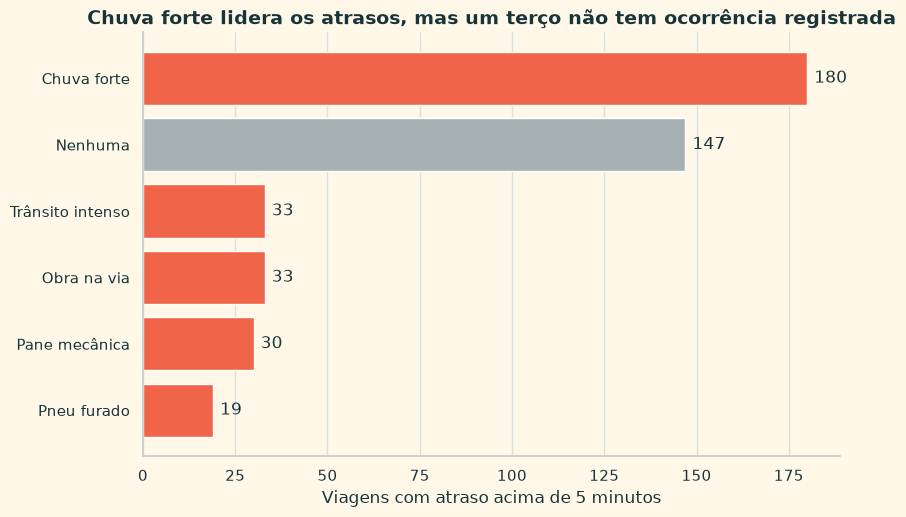

Viagens atrasadas por ocorrência e mês:


mes,2026-02,2026-03,2026-04,2026-05
ocorrencia,,,,
Chuva forte,14,97,56,13
Nenhuma,12,16,52,67
Obra na via,0,0,17,16
Pane mecânica,3,9,6,12
Pneu furado,4,5,5,5
Trânsito intenso,12,7,4,10


In [15]:
late = data[data["pontual"].eq(False)]
occurrences = late["ocorrencia"].value_counts().sort_values()
bar_colors = [GRAY if label == "Nenhuma" else CORAL for label in occurrences.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(occurrences.index, occurrences.values, color=bar_colors)
ax.bar_label(bars, padding=5)
ax.set(title="Chuva forte lidera os atrasos, mas um terço não tem ocorrência registrada",
       xlabel="Viagens com atraso acima de 5 minutos", ylabel="")
ax.grid(axis="y", visible=False)
sns.despine()
plt.show()

print("Viagens atrasadas por ocorrência e mês:")
display(pd.crosstab(late["ocorrencia"], late["mes"]))

**Evidência:** chuva forte aparece em 180 viagens atrasadas; 147 atrasos não têm ocorrência registrada. Pane mecânica tem mediana mais alta, mas apenas 30 registros. Ao longo dos meses, chuva forte domina em março (97 atrasos) e some em maio (13), enquanto “Obra na via” cresce de zero em fevereiro e março para 17 em abril e 16 em maio, e “Nenhuma” sobe de 12 em fevereiro para 67 em maio.  
**Interpretação:** chuva é frequente e pane é severa; nenhum dos dois, isoladamente, explica a concentração temporal e geográfica. A ocorrência que cresce junto com a ruptura é obra, e o aumento de atrasos sem ocorrência registrada sugere subnotificação.  
**Hipótese:** ocorrências pontuais agravam o resultado, enquanto a ruptura tem componente estrutural.  
**Limitação:** o campo depende do registro do motorista e pode sofrer subnotificação.

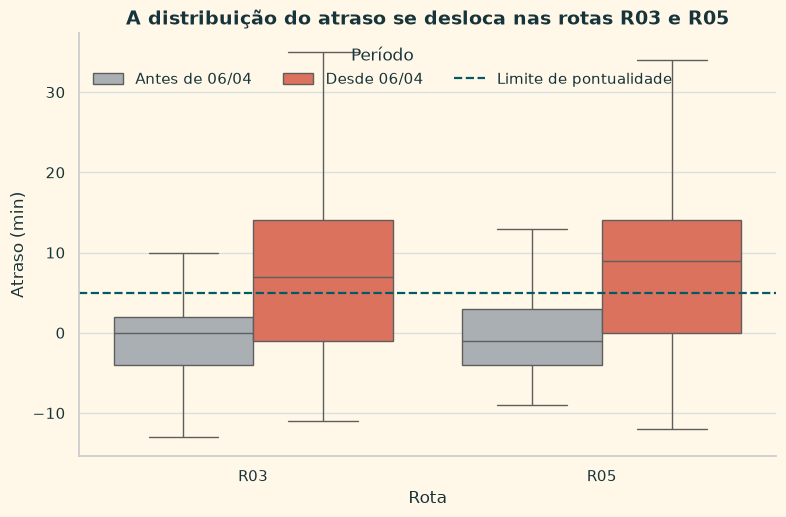

média  mediana  desvio
rota periodo_ruptura                        
R03  Antes de 06/04     0.2      0.0     7.0
     Desde 06/04        7.2      7.0    10.7
R05  Antes de 06/04     0.1     -1.0     6.8
     Desde 06/04        7.7      9.0    10.5

In [16]:
box_data = data[data["rota"].isin(["R03", "R05"])]
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=box_data, x="rota", y="atraso_min", hue="periodo_ruptura",
            hue_order=["Antes de 06/04", "Desde 06/04"],
            palette=[GRAY, CORAL], showfliers=False, ax=ax)
ax.axhline(5, color=TEAL, ls="--", lw=1.6, label="Limite de pontualidade")
ax.set(title="A distribuição do atraso se desloca nas rotas R03 e R05",
       xlabel="Rota", ylabel="Atraso (min)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Período", frameon=False, ncol=3, loc="upper left")
sns.despine()
plt.show()

display(
    box_data.groupby(["rota", "periodo_ruptura"])["atraso_min"]
    .agg(média="mean", mediana="median", desvio="std")
    .round(1)
)

**Evidência:** a mediana das duas rotas passa de valores próximos de zero para patamares acima do limite de pontualidade.  
**Interpretação:** não é apenas um pequeno conjunto de extremos; a distribuição inteira se desloca.  
**Hipótese:** a operação cotidiana das duas rotas mudou após 06/04.  
**Média ou mediana?** Na base tratada as duas contam a mesma história: em R03 passam de 0,2 e 0,0 para 7,2 e 7,0 min, e em R05 de 0,1 e -1,0 para 7,7 e 9,0. Na base bruta isso não valia, pois a média geral (2,51 min) era puxada por seis extremos e a mediana (-1 min) não. A mediana é a medida mais segura para reportar.  
**Limitação:** o boxplot agrega manhã, tarde e noite; o heatmap anterior é necessário para localizar o turno.

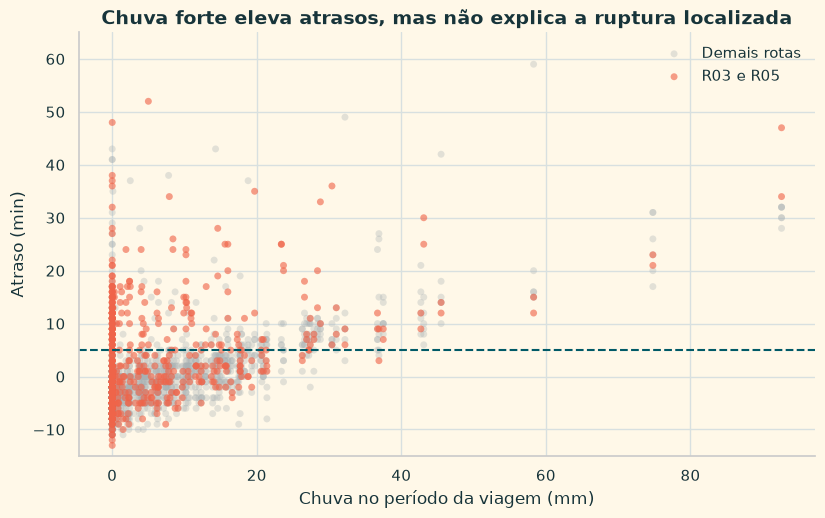

Correlação de Spearman entre chuva e atraso: 0.46
Desde 06/04, turnos diurnos, por faixa de chuva:


viagens           pontualidade           
grupo_rotas      Demais rotas R03 e R05 Demais rotas  R03 e R05
chuva_mm                                                       
Sem chuva                 299        99    95.317726  26.262626
Leve (0-10]               149        50    95.973154       16.0
Moderada (10-25]           83        28    80.722892   3.571429
Forte (>25)                30        10          0.0        0.0

In [17]:
rain = data.dropna(subset=["chuva_mm", "atraso_min"])
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for group, color, alpha in [("Demais rotas", GRAY, 0.32), ("R03 e R05", CORAL, 0.62)]:
    subset = rain[rain["grupo_rotas"].eq(group)]
    ax.scatter(subset["chuva_mm"], subset["atraso_min"], s=25, alpha=alpha,
               color=color, label=group, edgecolors="none")
ax.axhline(5, color=TEAL, ls="--", lw=1.5)
ax.set(title="Chuva forte eleva atrasos, mas não explica a ruptura localizada",
       xlabel="Chuva no período da viagem (mm)", ylabel="Atraso (min)", ylim=(-15, 65))
ax.legend(frameon=False)
sns.despine()
plt.show()

correlation = rain[["chuva_mm", "atraso_min"]].corr(method="spearman").iloc[0, 1]
print(f"Correlação de Spearman entre chuva e atraso: {correlation:.2f}")

rain_band = pd.cut(
    rain["chuva_mm"], [-np.inf, 0, 10, 25, np.inf],
    labels=["Sem chuva", "Leve (0-10]", "Moderada (10-25]", "Forte (>25)"],
)
controlled = rain[rain["data"].ge("2026-04-06") & rain["turno"].isin(["Manhã", "Tarde"])]
by_band = controlled.groupby(
    [rain_band[controlled.index], controlled["grupo_rotas"]], observed=True
)["pontual"].agg(viagens="size", pontualidade="mean")
by_band["pontualidade"] *= 100
print("Desde 06/04, turnos diurnos, por faixa de chuva:")
display(by_band.round(1).unstack("grupo_rotas"))

**Evidência:** há associação moderada entre chuva e atraso (Spearman ≈ 0,46), principalmente acima de 25 mm. Controlando período e turno (desde 06/04, manhã e tarde), R03/R05 têm 26% de pontualidade sem chuva e 16% com chuva leve, contra 95% e 96% nas demais rotas. Com chuva forte as duas caem a 0%, mas são poucas viagens (10 e 30).  
**Interpretação:** chuva funciona como fator agravante geral, não como explicação suficiente da ruptura: sem chuva, a diferença entre os grupos já é de quase 70 pontos percentuais.  
**Hipótese:** a restrição do corredor e a chuva podem se somar.  
**Limitação:** correlação não mede causalidade e chuva é medida no período, não ao longo de cada trajeto.

## Síntese numérica

Agora comparamos o grupo crítico com as demais rotas no mesmo período e nos mesmos turnos.

In [18]:
daytime_after = data[
    (data["data"] >= "2026-04-06")
    & data["turno"].isin(["Manhã", "Tarde"])
]
summary = daytime_after.groupby("grupo_rotas").agg(
    viagens=("atraso_min", "count"),
    pontualidade=("pontual", "mean"),
    mediana_atraso=("atraso_min", "median"),
    após_turno=("apos_inicio_turno", "sum"),
)
summary["pontualidade"] *= 100
display(summary.round(1))

roadwork = data[data["ocorrencia"].eq("Obra na via")]
print("Obra na via por rota:")
display(roadwork.groupby("rota").agg(
    registros=("data", "size"), início=("data", "min"), fim=("data", "max")
))

,viagens,pontualidade,mediana_atraso,após_turno
grupo_rotas,,,,
Demais rotas,573,88.481675,-2.0,14
R03 e R05,191,18.848168,12.0,53


Obra na via por rota:


,registros,início,fim
rota,,,
R03,19,2026-04-07,2026-05-28
R05,20,2026-04-08,2026-05-30


## Quadro final das hipóteses

| Hipótese | Evidência a favor | Evidência contra ou limitação | Decisão |
|---|---|---|---|
| H1 · Chuva explica a piora | Associação moderada; 180 atrasos com chuva forte | Afeta todas as rotas e não coincide com a ruptura localizada; sem chuva, R03/R05 têm 26% de pontualidade diurna contra 95% nas demais | **Inconclusiva como causa principal; mantida como agravante** |
| H2 · Restrição no corredor R03/R05 | Ruptura em 06/04, somente diurna; “Obra na via” surge em 07/04 apenas nessas rotas | Falta cronograma da obra e GPS por trecho | **Mantida como explicação mais plausível** |
| H3 · Falhas isoladas explicam a piora | Pane e pneu geram atrasos severos | Poucos casos e dispersos; distribuição inteira muda | **Rejeitada como explicação principal** |

O fato de R07 e R08, também operadas pela Viação Beta, permanecerem estáveis enfraquece uma explicação baseada apenas na empresa.

# Preparação da narrativa

## Mensagem central · 28 palavras

> **A pontualidade de R03 e R05 caiu nos turnos diurnos desde 6 de abril; obras no corredor são a explicação mais plausível, a confirmar com GPS e cronogramas.**

## Storyboard em três atos

| Ato | O que contar | O que mostrar |
|---|---|---|
| 1 · Problema | A pontualidade geral esconde uma ruptura localizada | Série temporal com marca em 06/04 |
| 2 · Investigação | Chuva agrava, mas não separa as rotas; limpeza remove distorções | Dispersão, heatmap e antes × depois |
| 3 · Resolução | Corredor compartilhado é a hipótese mais plausível; falta confirmação operacional | Gráfico explicativo e três ações |

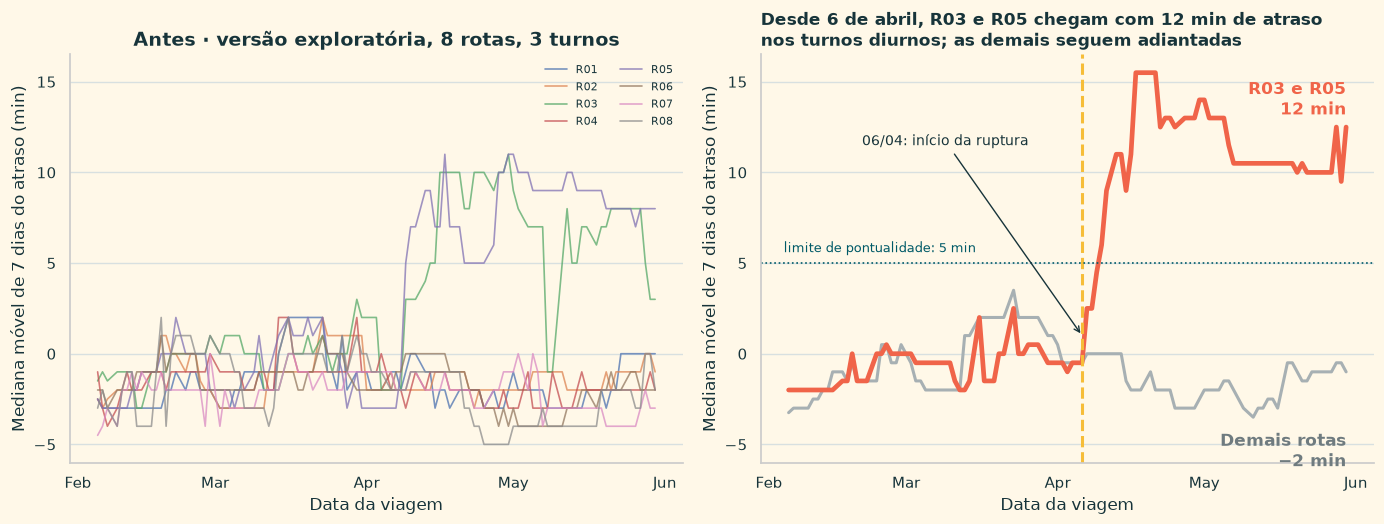

In [19]:
daytime = data[data["turno"].isin(["Manhã", "Tarde"])]
grouped = (
    daytime.groupby(["data", "grupo_rotas"])["atraso_min"].median().unstack()
    .rolling(7, min_periods=4).median()
)
median_after = (
    daytime[daytime["data"] >= "2026-04-06"]
    .groupby("grupo_rotas")["atraso_min"].median()
)

def minutes(value):
    return f"{value:.0f} min".replace("-", "−")

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)
for route in daily.columns:
    left.plot(daily.index, daily[route], lw=1.2, alpha=0.75, label=route)
left.set(title="Antes · versão exploratória, 8 rotas, 3 turnos", xlabel="Data da viagem",
         ylabel="Mediana móvel de 7 dias do atraso (min)")
left.legend(ncol=2, frameon=False, fontsize=8)

right.plot(grouped.index, grouped["Demais rotas"], color=GRAY, lw=2.2)
right.plot(grouped.index, grouped["R03 e R05"], color=CORAL, lw=3.4)
right.axvline(pd.Timestamp("2026-04-06"), color=YELLOW, lw=2.2, ls="--")
right.axhline(5, color=TEAL, lw=1.2, ls=":")
right.text(pd.Timestamp("2026-02-04"), 5.6, "limite de pontualidade: 5 min", color=TEAL, fontsize=9)
right.annotate("06/04: início da ruptura", xy=(pd.Timestamp("2026-04-06"), 1),
               xytext=(pd.Timestamp("2026-02-20"), 11.5),
               arrowprops={"arrowstyle": "->", "color": INK}, fontsize=10)
right.text(grouped.index[-1], median_after["R03 e R05"] + 1.2,
           f"R03 e R05\n{minutes(median_after['R03 e R05'])}", color=CORAL,
           fontweight="bold", ha="right")
right.text(grouped.index[-1], median_after["Demais rotas"] - 4.2,
           f"Demais rotas\n{minutes(median_after['Demais rotas'])}", color="#6F7B7F",
           fontweight="bold", ha="right")
right.set_title(
    "Desde 6 de abril, R03 e R05 chegam com 12 min de atraso\nnos turnos diurnos; as demais seguem adiantadas",
    fontsize=12.5, loc="left",
)
right.set(xlabel="Data da viagem", ylabel="Mediana móvel de 7 dias do atraso (min)")
right.tick_params(labelleft=True)

for axis in (left, right):
    axis.xaxis.set_major_locator(mdates.MonthLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis)
plt.tight_layout()
plt.show()

# Conclusão e recomendações

1. **O que aconteceu?** A pontualidade geral ficou em 81,9%, mas a média esconde uma mudança brusca nas rotas R03 e R05.
2. **Onde aconteceu?** Nos turnos da manhã e da tarde das duas rotas, ambas da zona Leste. O turno noturno permaneceu estável.
3. **Quando começou?** Em 6 de abril de 2026. O primeiro registro de “Obra na via” aparece em 7 de abril.
4. **Quais evidências sustentam a explicação?** Série temporal, heatmap rota × turno, deslocamento das distribuições e registros de obra somente em R03/R05.
5. **Qual explicação é mais plausível?** Interferência diurna no corredor compartilhado, compatível com obra na via. Chuva agrava o atraso, mas não explica a concentração: sem chuva, R03/R05 têm 26% de pontualidade nos turnos diurnos contra 95% nas demais rotas.
6. **O que ainda não pode ser afirmado?** Os dados não provam causalidade nem identificam o trecho exato.

### Próximas ações

- cruzar o período com cronograma e localização das obras públicas;
- coletar GPS e tempo por trecho de R03/R05 por duas semanas;
- testar desvio de rota ou antecipação de 15 minutos nos turnos diurnos, acompanhando pontualidade e tempo total.

### Pontos de aprendizado

- a média geral pode esconder um problema localizado;
- limpeza reproduzível muda números, mas uma conclusão robusta deve sobreviver a ela;
- mediana e distribuição são essenciais quando há extremos;
- associação visual não equivale a causalidade;
- um gráfico explicativo exige seleção, contraste e anotação.

In [20]:
output_columns = [
    "data", "turno", "rota", "zona_origem", "empresa",
    "horario_previsto", "horario_chegada", "atraso_min",
    "passageiros", "chuva_mm", "ocorrencia", "pontual",
    "apos_inicio_turno",
]
treated_path = (
    Path("dataset/dados_tratados_transporte_fretado.csv")
    if Path("dataset").is_dir()
    else Path("dados_tratados_transporte_fretado.csv")
)
data[output_columns].to_csv(treated_path, index=False, date_format="%Y-%m-%d")
print(f"Base tratada salva em: {treated_path}")

Base tratada salva em: dataset/dados_tratados_transporte_fretado.csv
